# Mobilesphere : Mobile Pricing Prediction

# 🎓 Project Title

**Mobilesphere: Mobile Phone Pricing Prediction Using Machine Learning**

---

## 🧩 Problem Statement

The mobile phone market is highly dynamic, with prices depending on multiple independent variables such as RAM, storage, battery capacity, camera specifications, screen size, and brand. The relationship between these features and the final price is often complex and not strictly linear. 

Therefore, there is a need for an intelligent predictive model that can learn pricing patterns from historical data. The goal of this project is to accurately predict the continuous price of a mobile phone based on its hardware and software specifications.

---

## 📖 Project Description

**Mobilesphere** is a machine learning-based project designed to predict mobile phone prices. The model analyzes various smartphone attributes (like Battery Capacity, RAM, Internal Storage, Camera Megapixels, Operating System, and Brand) to estimate the device's market price.

The project involves comprehensive data preprocessing, handling missing values, encoding categorical variables, and applying both linear and ensemble regression algorithms. By capturing patterns from existing mobile data, the system provides valuable pricing insights that can assist manufacturers, retailers, and consumers in making informed decisions.

---

## 📊 Dataset Description

The dataset consists of **Mobile Phone Specifications** containing both numerical and categorical features. Each row represents a specific smartphone model, and the features describe its hardware, software, and connectivity capabilities.

* **Brand & Model** – Manufacturer and device name (e.g., Apple iPhone 11)
* **Battery capacity (mAh)** – Size of the battery
* **Screen size (inches)** & **Resolution** – Display specifications
* **RAM (MB)** & **Internal storage (GB)** – Memory and storage capacities
* **Front & Rear camera** – Megapixel counts for both cameras
* **Operating system** – Android, iOS, Windows, etc.
* **Connectivity** – Wi-Fi, Bluetooth, GPS, 3G/4G/LTE support
* **Price (Target Column)** – The market price of the mobile phone

Each row represents a unique mobile phone in the market.

---

## 🎯 Target Variable (Dependent Variable)

### **Price**

The target variable represents the market price of the mobile phone.

Since the price is a continuous numerical value, this is a **regression problem**, where the goal is to predict the exact or approximate cost of the device based on its attributes.

---

## 🛠️ Methodology

1. **Data Loading and Exploration**
    * Importing the mobile dataset
    * Understanding the structure, rows, and columns
    * Checking for null or missing values

2. **Data Cleaning**
    * Handling missing values appropriately
    * Removing inconsistencies in specifications
    * Encoding categorical variables (e.g., Brand, Operating System)
    
3. **Feature Engineering**
    * Normalizing/Scaling numerical features like Battery Capacity and RAM
    * Transforming features to better represent non-linear relationships

4. **Exploratory Data Analysis (EDA)**
    * Distribution of mobile prices across different brands
    * Correlation between RAM/Storage and Price
    * Impact of Battery Capacity and Camera specs on the final price

5. **Train-Test Split**
    * Splitting the dataset into training and testing sets to evaluate model generalization

6. **Model Training**
    Training supervised machine learning regression models:
    * Linear Regression
    * Random Forest Regressor

7. **Model Evaluation & Comparison**
    * Evaluating models using standard regression metrics
    * Comparing the baseline Linear model with the advanced Random Forest model
    * Analyzing why certain models capture complex device pricing better

---

## 🤖 Machine Learning Models Used

The following regression algorithms are implemented and compared:

* **Linear Regression** – Used as a baseline model due to its simplicity and interpretability. It helps in understanding the linear impact of specific features on the price.
* **Random Forest Regressor** – An ensemble learning method chosen for its ability to capture complex, non-linear relationships between phone features (like brand value + camera quality) and price, effectively reducing overfitting.

---

## 📈 Evaluation Metrics

To measure the performance and accuracy of the regression models, the following metrics are used:

* **R² Score (Coefficient of Determination)** – Measures the proportion of variance in the price that is predictable from the features.
* **Mean Absolute Error (MAE)** – Shows the absolute average distance between the predicted price and the actual price.
* **Mean Squared Error (MSE) / Root Mean Squared Error (RMSE)** – Penalizes larger errors, giving insight into the model's prediction accuracy.

---

## ✅ Expected Outcome

* Accurate and robust prediction of mobile phone prices.
* Identification of key features (like RAM, Brand, or Storage) that heavily influence a phone's market value.
* A clear comparison showing that ensemble models (Random Forest) outperform linear models by capturing non-linear pricing interactions.
* A solid foundation for a deployable pricing engine for e-commerce platforms or a dynamic dashboard for market analysts.
---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

### Importing Required Libraries

This cell imports necessary libraries for data processing, visualization, and building machine learning models.

## 📖 Data Loading and Exploration

In [2]:
# Load dataset
df = pd.read_csv('data/cleaned_mobile_data.csv')
# Drop irrelevant columns
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,Name,Brand,Model,Battery capacity (mAh),Screen size (inches),Touchscreen,Resolution x,Resolution y,Processor,RAM (MB),...,Rear camera,Front camera,Operating system,Wi-Fi,Bluetooth,GPS,Number of SIMs,3G,4G/ LTE,Price
0,OnePlus 7T Pro McLaren Edition,OnePlus,7T Pro McLaren Edition,4085,6.67,Yes,1440,3120,8,12000,...,48.0,16.0,Android,Yes,Yes,Yes,2,Yes,Yes,58998
1,Realme X2 Pro,Realme,X2 Pro,4000,6.50,Yes,1080,2400,8,6000,...,64.0,16.0,Android,Yes,Yes,Yes,2,Yes,Yes,27999
2,iPhone 11 Pro Max,Apple,iPhone 11 Pro Max,3969,6.50,Yes,1242,2688,6,4000,...,12.0,12.0,iOS,Yes,Yes,Yes,2,Yes,Yes,106900
3,iPhone 11,Apple,iPhone 11,3110,6.10,Yes,828,1792,6,4000,...,12.0,12.0,iOS,Yes,Yes,Yes,2,Yes,Yes,62900
4,LG G8X ThinQ,LG,G8X ThinQ,4000,6.40,Yes,1080,2340,8,6000,...,12.0,32.0,Android,Yes,Yes,Yes,1,No,No,49990


### Loading the Dataset

We load the cleaned mobile price prediction dataset and drop unnecessary columns.

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1359, 21)


### Checking the Shape of the Dataset

Outputs the number of rows and columns in the dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    1359 non-null   object 
 1   Brand                   1359 non-null   object 
 2   Model                   1359 non-null   object 
 3   Battery capacity (mAh)  1359 non-null   int64  
 4   Screen size (inches)    1359 non-null   float64
 5   Touchscreen             1359 non-null   object 
 6   Resolution x            1359 non-null   int64  
 7   Resolution y            1359 non-null   int64  
 8   Processor               1359 non-null   int64  
 9   RAM (MB)                1359 non-null   int64  
 10  Internal storage (GB)   1359 non-null   float64
 11  Rear camera             1359 non-null   float64
 12  Front camera            1359 non-null   float64
 13  Operating system        1359 non-null   object 
 14  Wi-Fi                   1359 non-null   

### Dataset Information Overview

Displays the data types and non-null counts for each feature.

In [5]:
df.describe()

,Battery capacity (mAh),Screen size (inches),Resolution x,Resolution y,Processor,RAM (MB),Internal storage (GB),Rear camera,Front camera,Number of SIMs,Price
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,2938.489330,5.291310,811.543046,1490.777778,5.551141,2488.777778,30.654864,12.070199,7.037969,1.833701,11465.825607
std,873.514133,0.671357,270.707271,557.780120,2.196562,1664.440386,36.950241,8.948337,6.295448,0.374457,13857.497077
min,1010.000000,2.400000,240.000000,320.000000,1.000000,64.000000,0.064000,0.000000,0.000000,1.000000,494.000000
25%,2300.000000,5.000000,720.000000,1280.000000,4.000000,1000.000000,8.000000,8.000000,2.000000,2.000000,4763.500000
50%,3000.000000,5.200000,720.000000,1280.000000,4.000000,2000.000000,16.000000,12.200000,5.000000,2.000000,6999.000000
75%,3500.000000,5.700000,1080.000000,1920.000000,8.000000,3000.000000,32.000000,13.000000,8.000000,2.000000,11999.000000
max,6000.000000,7.300000,2160.000000,3840.000000,10.000000,12000.000000,512.000000,108.000000,48.000000,3.000000,174990.000000


### Statistical Summary of Numerical Features

Provides basic statistical details like mean, standard deviation, min, and max values for numerical columns.

## 🛠️ Data Cleaning & Feature Engineering

In [6]:
# Checking for missing values
df.isnull().sum()

Name                      0
Brand                     0
Model                     0
Battery capacity (mAh)    0
Screen size (inches)      0
Touchscreen               0
Resolution x              0
Resolution y              0
Processor                 0
RAM (MB)                  0
Internal storage (GB)     0
Rear camera               0
Front camera              0
Operating system          0
Wi-Fi                     0
Bluetooth                 0
GPS                       0
Number of SIMs            0
3G                        0
4G/ LTE                   0
Price                     0
dtype: int64

### Visualizing Missing Values

Checks for any missing or null values in the dataset using the isnull().sum() method.

In [7]:
# Encoding categorical variables
label_encoders = {}
categorical_cols = ['Brand', 'Model', 'Touchscreen', 'Operating system', 'Wi-Fi', 'Bluetooth', 'GPS', '3G', '4G/ LTE']

df_encoded = df.copy()
for col in categorical_cols:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le
        
df_encoded.head()

,Name,Brand,Model,Battery capacity (mAh),Screen size (inches),Touchscreen,Resolution x,Resolution y,Processor,RAM (MB),...,Rear camera,Front camera,Operating system,Wi-Fi,Bluetooth,GPS,Number of SIMs,3G,4G/ LTE,Price
0,OnePlus 7T Pro McLaren Edition,44,49,4085,6.67,1,1440,3120,8,12000,...,48.0,16.0,0,1,1,1,2,1,1,58998
1,Realme X2 Pro,53,1142,4000,6.50,1,1080,2400,8,6000,...,64.0,16.0,0,1,1,1,2,1,1,27999
2,iPhone 11 Pro Max,3,1288,3969,6.50,1,1242,2688,6,4000,...,12.0,12.0,6,1,1,1,2,1,1,106900
3,iPhone 11,3,1286,3110,6.10,1,828,1792,6,4000,...,12.0,12.0,6,1,1,1,2,1,1,62900
4,LG G8X ThinQ,29,522,4000,6.40,1,1080,2340,8,6000,...,12.0,32.0,0,1,1,1,1,0,0,49990


### Encoding Categorical Variables

Converts categorical text variables into numerical format using Label Encoding so they can be processed by machine learning models.

## 📊 Exploratory Data Analysis (EDA)

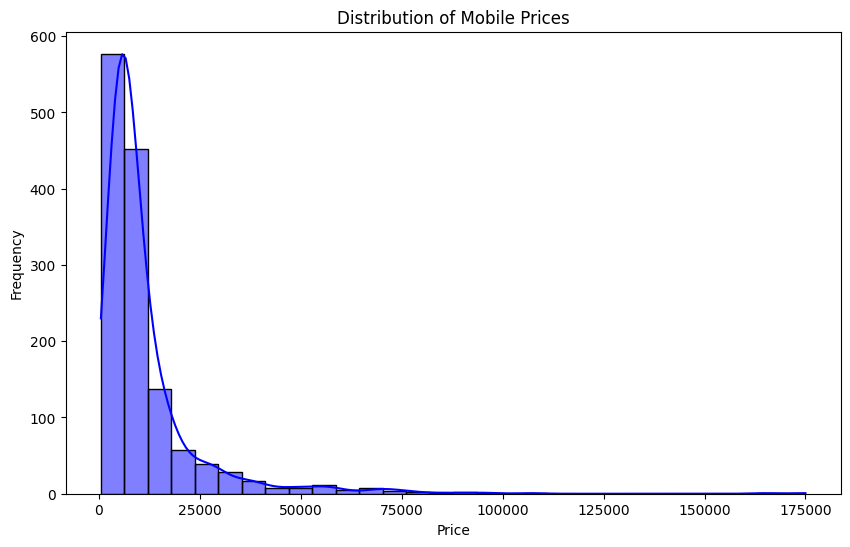

In [8]:
# Distribution of Mobile Prices
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=30, kde=True, color='blue')
plt.title('Distribution of Mobile Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

### Histogram: Distribution of Mobile Prices

Visualizes the frequency distribution of mobile prices to understand overall pricing trends.

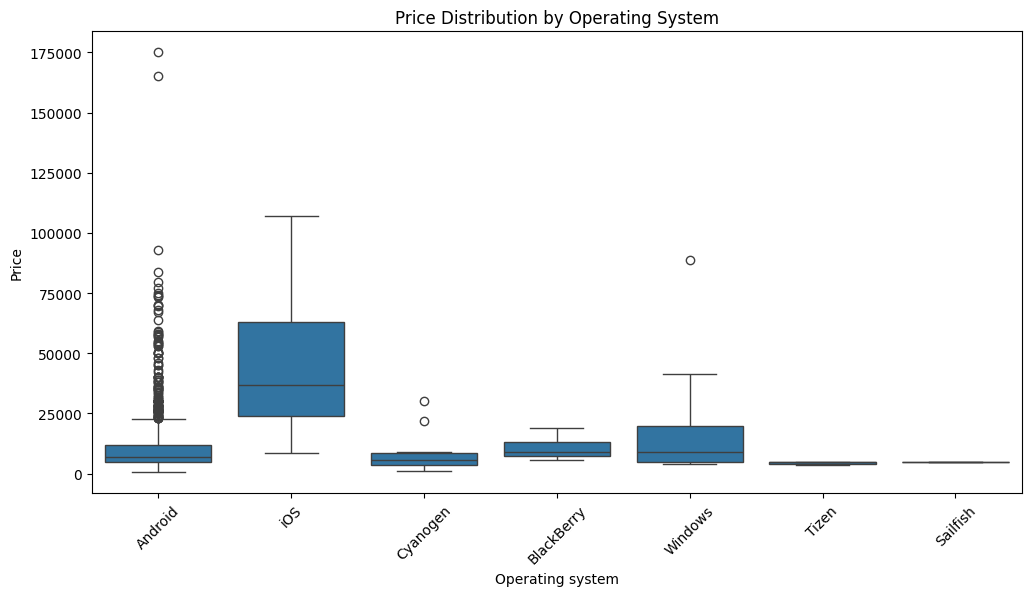

In [9]:
# Price distribution by Operating System
plt.figure(figsize=(12, 6))
sns.boxplot(x='Operating system', y='Price', data=df)
plt.title('Price Distribution by Operating System')
plt.xticks(rotation=45)
plt.show()

### Box Plot: Price Distribution by Operating System

Analyzes how mobile prices vary across different operating systems.

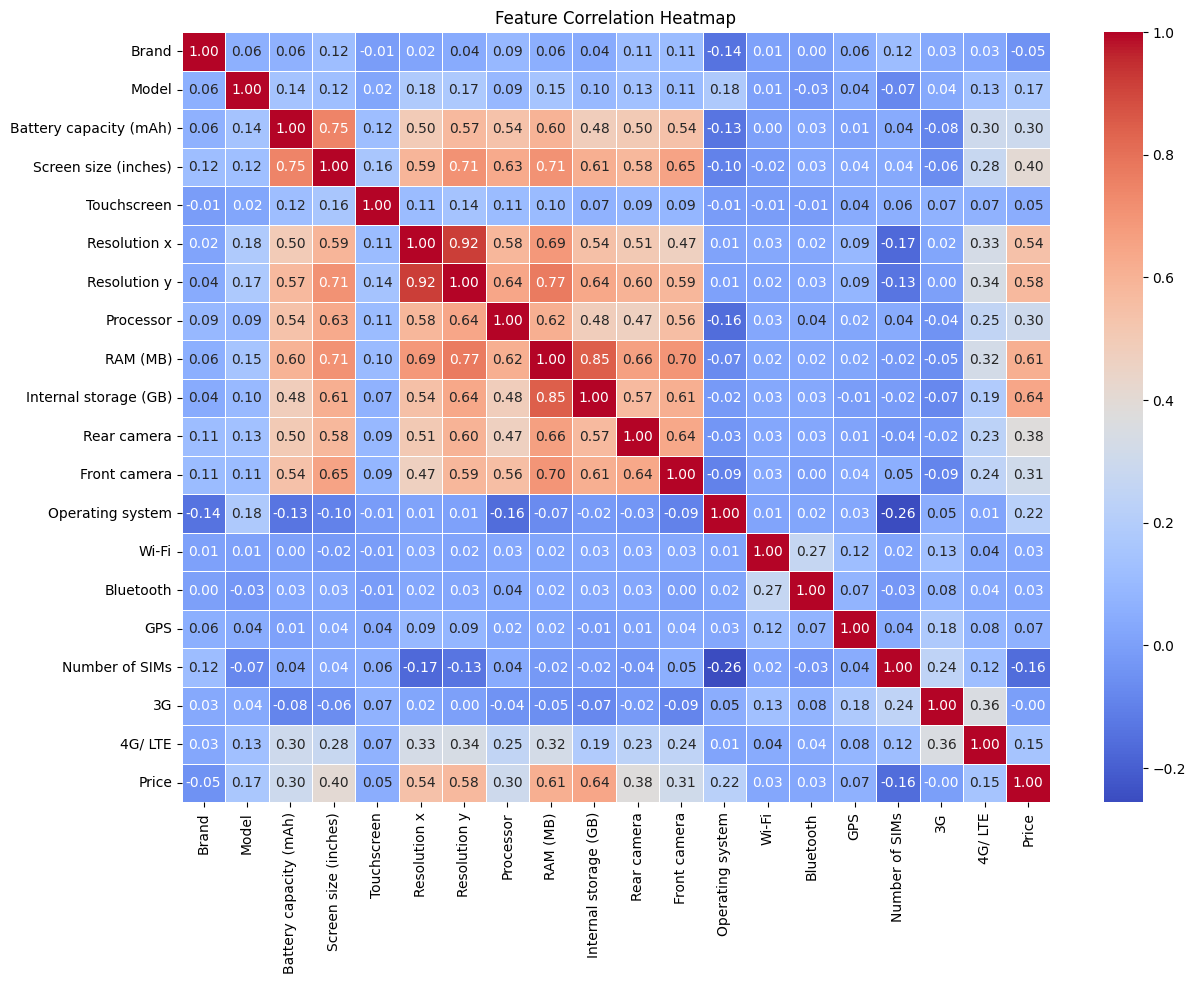

In [10]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
corr = df_encoded.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

### Correlation Heatmap of Features

Displays the correlation between different numerical features in the dataset.

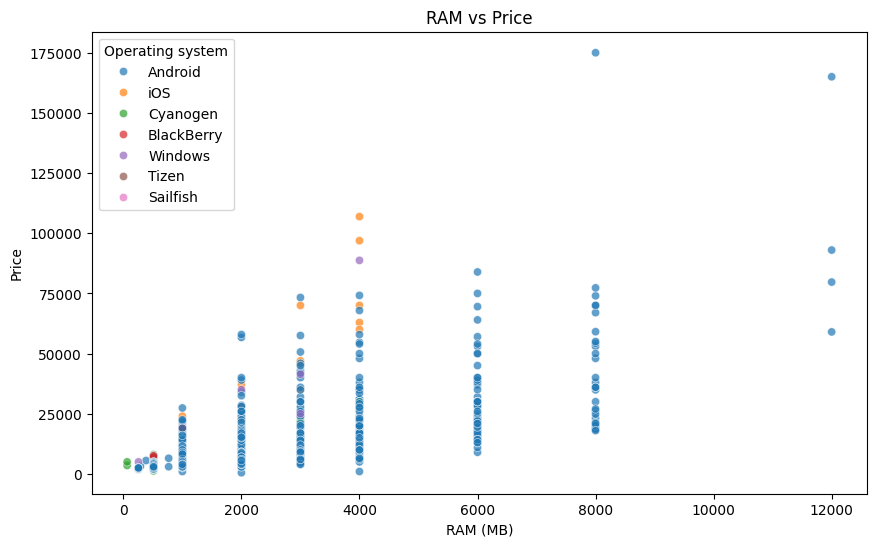

In [11]:
# RAM vs Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='RAM (MB)', y='Price', data=df, hue='Operating system', alpha=0.7)
plt.title('RAM vs Price')
plt.show()

### Scatter Plot: RAM vs Price

Visualizes the relationship between RAM size and mobile price, separated by operating system.

## ✂️ Train-Test Split

In [12]:
# Define features (X) and target variable (y)
X = df_encoded.drop(columns=['Price', 'Name'], errors='ignore')
y = df_encoded['Price']

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Training Features Shape: (1087, 19)
Testing Features Shape: (272, 19)


### Splitting Dataset into Training and Testing Sets

Separates the features and the target variable (Price), then splits the dataset into training and testing subsets (80/20).

## 🤖 Model 1: Linear Regression

In [13]:
# Initialize and train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make Predictions
y_pred_lr = lr_model.predict(X_test)

### Training Linear Regression Model

Initializes and trains a Linear Regression model, then makes predictions on the test set.

## 🌲 Model 2: Random Forest Regressor

In [14]:
# Initialize and train Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make Predictions
y_pred_rf = rf_model.predict(X_test)

### Training Random Forest Regressor Model

Initializes and trains a Random Forest Regressor model for potentially better accuracy.

## 📈 Evaluation Metrics & Comparison

In [ ]:
# Function to evaluate models
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} Performance ---")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")

### Model Evaluation

Compares the performance of Linear Regression and Random Forest models using MAE, RMSE, and R-squared metrics.

In [ ]:
# Visualizing Predictions -> Linear Regression vs Random Forest
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted - Linear Regression')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6, color='g')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted - Random Forest')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.tight_layout()
plt.show()

### Visualizing Actual vs Predicted Prices

Creates scatter plots comparing actual test prices against the predictions made by both models.

In [ ]:
# Feature Importance from Random Forest
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### Feature Importance Analysis

Displays the importance of different features according to the trained Random Forest model.

## ✅ Expected Outcome & Conclusion
From the evaluation metrics and graphs, we can conclude that the **Random Forest Regressor** performs significantly better than **Linear Regression**. 
This is because mobile phone pricing relies on non-linear interactions between multiple features, such as RAM, Internal Storage, and Battery Capacity, which the Random Forest model captures much more effectively.